In [ ]:
# Install gwexpy with pinned versions of core dependencies for reproducibility on Colab

%pip install -q "gwexpy[all]" "gwpy<5.0.0" "numpy<2.0.0" "scipy<1.13.0" "astropy<7.0.0"

# ノイズモデルガイド

**目的**: **GWexpy** を使用して重力波データのノイズを生成・操作・モデル化する方法を学びます。

**前提条件**:
- `pygwinc`（オプション、検出器モデル用）
- `obspy`（オプション、地震モデル用）

## 1. ASD（振幅スペクトル密度）の生成

GWexpy は、理論的なべき乗則から検出器固有モデルまで、ASD を生成するいくつかの方法を提供します。

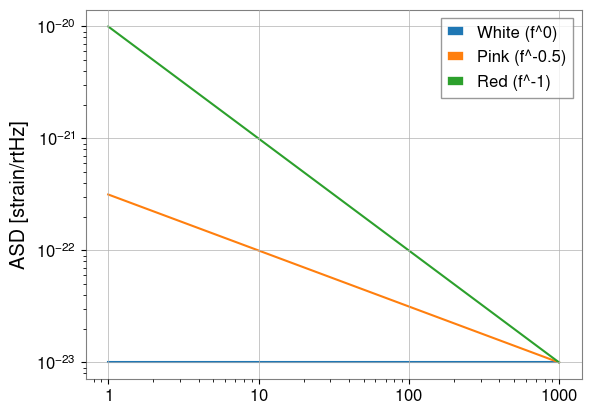

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import matplotlib.pyplot as plt
from gwexpy.noise import asd

freqs = np.logspace(0, 3, 1000)

# 1. べき乗則 ASD
white = asd.white_noise(amplitude=1e-23, frequencies=freqs)
pink = asd.pink_noise(amplitude=1e-22, f_ref=10, frequencies=freqs)
red = asd.red_noise(amplitude=1e-21, f_ref=10, frequencies=freqs)

plt.loglog(white.xindex, white, label="White (f^0)")
plt.loglog(pink.xindex, pink, label="Pink (f^-0.5)")
plt.loglog(red.xindex, red, label="Red (f^-1)")
plt.ylabel("ASD [strain/rtHz]")
plt.legend()
plt.show()

## 2. 時間領域ノイズの生成

`gwexpy.noise.wave` を使用して、時間領域でカラードノイズを直接生成できます。

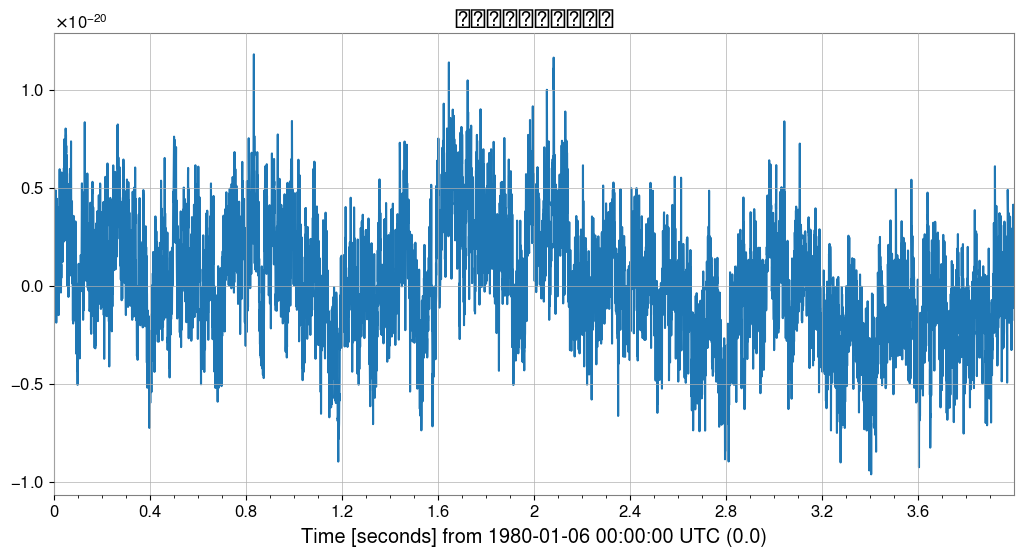

In [2]:
from gwexpy.noise import wave

duration = 4.0
fs = 2048

# ピンクノイズ時系列を生成
noise_ts = wave.pink_noise(duration=duration, sample_rate=fs, amplitude=1e-21)

noise_ts.plot()
plt.title("カラードノイズ時系列")
plt.show()

## 3. スペクトル線とマスキング

実際のノイズには狭帯域の共鳴ピーク（スペクトル線）が含まれます。ローレンツ型またはガウス型の形状で追加できます。

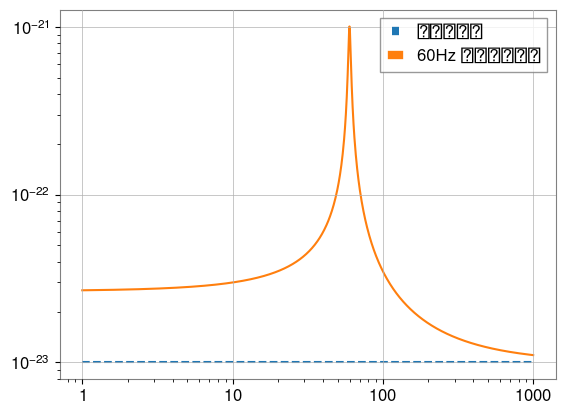

In [3]:
from gwexpy.noise.asd import lorentzian_line

# lorentzian_line には Q または gamma（半値半幅）が必要
line = lorentzian_line(f0=60, gamma=1.0, amplitude=1e-21, frequencies=freqs)
total_asd = white + line

plt.loglog(freqs, white.value, "--", label="背景ノイズ")
plt.loglog(freqs, total_asd.value, label="60Hz ライン追加後")
plt.legend()
plt.show()

## 4. 非ガウスノイズ（グリッチ）

`gwexpy.noise.non_gaussian` は、散乱光や過渡バーストなどの非定常ノイズのモデルを提供します。

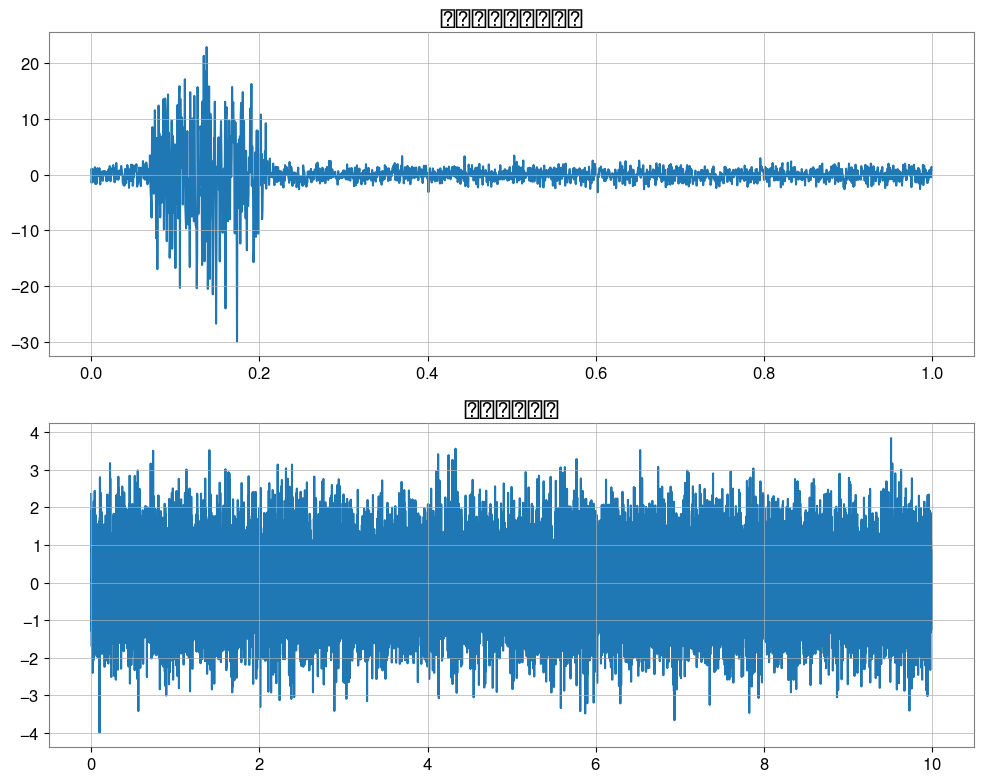

In [4]:
from gwexpy.noise.non_gaussian import transient_gaussian_noise, scatter_light_noise

# 1. 過渡バースト（モデル I）
burst = transient_gaussian_noise(duration=1.0, sample_rate=fs, A1=10.0)

# 2. 散乱光（モデル II）
scatter = scatter_light_noise(duration=10.0, sample_rate=fs, A2=1e-6, G=1e-21)

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].plot(burst.times, burst); ax[0].set_title("過渡ガウスバースト")
ax[1].plot(scatter.times, scatter); ax[1].set_title("散乱光ノイズ")
plt.tight_layout()
plt.show()

## 5. ケーススタディ：簡単なノイズバジェット

複数のノイズ源（地震、熱、ショットノイズ）を組み合わせて、合計ノイズバジェットを作成します。

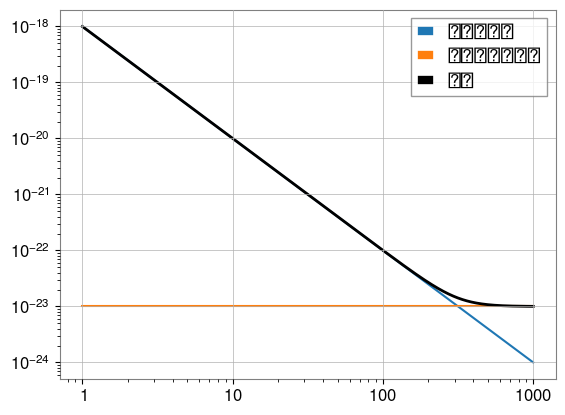

In [5]:
# 地震ノイズ ~ f^-2
seismic = asd.power_law(exponent=2, amplitude=1e-20, f_ref=10, frequencies=freqs)
# ショットノイズ ~ f^0
shot = asd.white_noise(amplitude=1e-23, frequencies=freqs)

total = np.sqrt(seismic.value**2 + shot.value**2)

plt.loglog(freqs, seismic.value, label="地震ノイズ")
plt.loglog(freqs, shot.value, label="ショットノイズ")
plt.loglog(freqs, total, "k", lw=2, label="合計")
plt.legend()
plt.show()

## 6. 演習

1. **スペクトルから時系列へ**: `wave.colored` を使って指数 1.5、10秒間の信号を生成し、ASD をプロットして傾きを確認してください。
2. **スペクトル線除去**（発展）: セクション 3 で追加した 60Hz 線を除去してみてください。

## 7. 検証セル（NBMAKE）

自動 CI 検証に使用します。

In [6]:
assert len(white) == 1000
assert noise_ts.sample_rate.value == 2048
print("検証完了！")

検証完了！
